### PROBLEM 1 [45 points]

The differential diagnosis of erythemato-squamous diseases is a real problem in dermatology. They all share the clinical features of erythema and scaling, with very little differences. The diseases in this group are psoriasis, seboreic dermatitis, lichen planus, pityriasis rosea, cronic dermatitis, and pityriasis rubra pilaris. Usually a biopsy is necessary for the diagnosis but unfortunately these diseases share many histopathological features as well. Another difficulty for the differential diagnosis is that a disease may show the features of another disease at the beginning stage and may have the characteristic features at the following stages. Patients were first evaluated clinically with 12 features. Afterwards, skin samples were taken for the evaluation of 22 histopathological features. The values of the histopathological features are determined by an analysis of the samples under a microscope.

In the dataset constructed for this domain, the family history feature has the value 1 if any of these diseases has been observed in the family, and 0 otherwise. The age feature simply represents the age of the patient. Every other feature (clinical and histopathological) was given a degree in the range of 0 to 3. Here, 0 indicates that the feature was not present, 3 indicates the largest amount possible, and 1, 2 indicate the relative intermediate values.

Assuming that the list of diseases in this group are complete (total 6 types), use the dataset to address the following list of objectives:

a. Let’s try determining the type of disease based on the patient’s Age. Use gradient descent (GD) to build your regression model (model1). Start by writing the GD algorithm and then implement it using a programming language of your choice.

b. Use random forest on the clinical as well as histopathological attributes to classify the disease type (model2). 

c. Use kNN on the clinical attributes and histopathological attributes to classify the disease type and report your accuracy (model3). 

d. Finally, use two different clustering algorithms and see how well these attributes can determine the disease type (model4 and model5). 

Make sure to report your actual model for each of the above. This means providing appropriate details containing the features used, parameters learned/estimated, and any inputs (e.g., number of clusters, error limit) that go into the technique. When appropriate, perform multiple runs of the same technique and report average values or their spread.

e. Now, compare and contrast the five models you built. Having done both classification and clustering on the same dataset, what can you say about this data and/or the techniques you used? Write your thoughts in 2-3 paragraphs. 

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import sklearn.linear_model as lm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.special import softmax
from sklearn.preprocessing import OneHotEncoder
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
import pprint
pp = pprint.PrettyPrinter(indent = 4)

In [2]:
derm_df = pd.read_csv('dermatology.csv', sep = '\t')
derm_df.head()

,Erythema,Scathing,Definite Borders,Itching,Koebner,Polygonal,Follicular,Oral,Knee,Scalp,...,Disapperance,Vacuolisation,Spongiosis,Retes,Follicular.1,Perifollicular,Inflamatory,Band-like,Age,Disease
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [3]:
# Converting age to int, as it's currently of object type, containing ? str, and clean df
derm_df = derm_df[derm_df.Age != '?']
derm_df['Age'] = pd.to_numeric(derm_df['Age'])
df_clean = derm_df[derm_df.notna()].copy()

# Normalize data
X = df_clean.drop('Disease', axis = 1).copy()
y = df_clean['Disease'].copy()

X_std = X.std()
x_mean = X.mean()
y_std = y.std()
y_mean = y.mean()

X_norm = (X - x_mean) / X_std
y_norm = (y - y_mean) / y_std

# Scale the df as a test
scaler = MinMaxScaler()
X[X.columns] = scaler.fit_transform(X[X.columns])

a. Let’s try determining the type of disease based on the patient’s Age. Use gradient descent (GD) to build your regression model (model1). Start by writing the GD algorithm and then implement it using a programming language of your choice.

In [4]:
# Reference: https://medium.com/data-science/multiclass-logistic-regression-from-scratch-9cc0007da372 and https://www.youtube.com/watch?v=wY3PJGZEyY4&t=1s
# Reference: https://medium.com/@ashisharora2204/logistic-regression-maximum-likelihood-estimation-gradient-descent-a7962a452332
def predict_multiclass(X, W, b):
    z = X.dot(W) + b
    return softmax(z, axis = 1) # From Sophin in Teams chat

# Cross entropy loss formula https://datascience.stackexchange.com/questions/20296/cross-entropy-loss-explanation
def entropy_loss(X, y_one_hot, W, b):
    # Calculate loss function (entropy loss)
    m = len(y_one_hot)
    predictions = predict_multiclass(X, W, b)
    loss = -1/m * np.sum(y_one_hot * np.log(predictions + 1e-7)) # 1e-7 to make sure we're not taking log of 0
    return loss

def log_gradient_descent(X, y, alpha = 0.01, iterations = 5000):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2
    )
    
    # One-hot encode labels for softmax training, https://www.youtube.com/watch?v=rsyrZnZ8J2o
    encoder = OneHotEncoder(sparse_output = False)
    y_train_one_hot = encoder.fit_transform(y_train.reshape(-1, 1))
    num_diseases = len(np.unique(y_train))
    
    # Initialize parameters
    m, n = X_train.shape
    W = np.zeros((n, num_diseases))  # weight 
    b = np.zeros((1, num_diseases))  # bias
    loss_history = []
    
    # Run gradient descent    
    for i in range(iterations):
        # Get prediction with softmax
        y_pred = predict_multiclass(X_train, W, b)

        # Calculate loss
        loss = entropy_loss(X_train, y_train_one_hot, W, b)
        loss_history.append(loss)
        
        # Partial derivatives for gradient
        pd_W = (1/m) * X_train.T.dot(y_pred - y_train_one_hot) # partial derivative for weights
        pd_b = (1/m) * np.sum(y_pred - y_train_one_hot, axis = 0, keepdims = True) # partial derivative for bias
    
        # Update rule
        W = W - alpha * pd_W
        b = b - alpha * pd_b

        # Print out loss values as we iterate
        if i % 500 == 0:
            print(f"iteration {i}: loss = {loss:.4f}")

    # Run an accuracy test
    z_test = X_test.dot(W) + b
    y_pred_test = softmax(z_test, axis = 1)
    y_pred_disease = np.argmax(y_pred_test, axis = 1)

    # Convert one-hot prediction back to original disease labels
    y_pred_original = encoder.categories_[0][y_pred_disease] # https://www.geeksforgeeks.org/machine-learning/reversing-sklearnonehotencoder-transform-to-recover-original-data/

    acc = accuracy_score(y_test, y_pred_original)
    print("\nGradient Descent (Multiclass Regression with Age)")
    print(f"Accuracy: {acc * 100:.4f}%")
    print("Weights and biases per disease:")
    for i in range(num_diseases):
        print(f"Disease {i + 1}: W = {W[0, i]:.4f}, b = {b[0, i]:.4f}")

    return W, b, loss_history

In [5]:
# Grab data values of disease and normalized age
new_X = X['Age'].values.reshape(-1, 1)
new_y = df_clean['Disease'].values - 1  # Convert to 0-5 (Python indexing)

# Grab number of diseases
num_diseases = len(np.unique(new_y))
print(f"The dataset has: {len(new_X)} samples with {num_diseases} diseases")

# Run log gradient descent using cross entropy as loss formula
W, b, loss_history = log_gradient_descent(new_X, new_y)

The dataset has: 358 samples with 6 diseases
iteration 0: loss = 1.7918
iteration 500: loss = 1.7134
iteration 1000: loss = 1.6998
iteration 1500: loss = 1.6946
iteration 2000: loss = 1.6912
iteration 2500: loss = 1.6886
iteration 3000: loss = 1.6862
iteration 3500: loss = 1.6840
iteration 4000: loss = 1.6819
iteration 4500: loss = 1.6798

Gradient Descent (Multiclass Regression with Age)
Accuracy: 40.2778%
Weights and biases per disease:
Disease 1: W = 0.6019, b = 0.3740
Disease 2: W = 0.0396, b = 0.0946
Disease 3: W = 0.4829, b = 0.0386
Disease 4: W = 0.0216, b = -0.0060
Disease 5: W = 0.0277, b = -0.1039
Disease 6: W = -1.1737, b = -0.3974


In [26]:
# Check gradient descent with SKlearn Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
        new_X, new_y, test_size = 0.2)

# https://danhergir.medium.com/implementing-multi-class-logistic-regression-with-scikit-learn-53d919b72c13
clf = LogisticRegression(solver = "newton-cg" ,multi_class = "ovr").fit(X_train, y_train)
clf_acc = accuracy_score(y_test, clf.predict(X_test))

print("\nMulticlass Logistic Regression with Scikit Learn")
print(f"Accuracy: {clf_acc * 100:.4f}%")


Multiclass Logistic Regression with Scikit Learn
Accuracy: 38.8889%


b. Use random forest on the clinical as well as histopathological attributes to classify the disease type (model2). 

In [46]:
# Create an accuracy test for random forest with train test split
def forest_accuracy_test(X, y, model, features, iterations):
    test_accuracy = []
    train_accuracy = []

    # Run multiple iterations to get an average for accuracy, with 80/20 test split
    for i in range(iterations):
        # Test for accuracy with 80/20 split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        
        # Make random forest model
        tree_model = RandomForestClassifier()
        tree_model.fit(X_train, y_train)
        y_pred_test = tree_model.predict(X_test)
        y_pred_train = tree_model.predict(X_train)

        # Calculate the accuracy and append to accuracy list
        test_accuracy.append(accuracy_score(y_test, y_pred_test))
        train_accuracy.append(accuracy_score(y_train, y_pred_train))
        
    # Return average accuracy over defined iterations
    test_avg_acc = sum(test_accuracy)/len(test_accuracy)
    train_avg_acc = sum(train_accuracy)/len(train_accuracy)
    print(f"Using {model} with {features} over {str(iterations)} iterations, we get an average accuracy over the test set of {test_avg_acc * 100:.4f}%")
    print(f"Accuracy range: {min(test_accuracy) * 100:.4f}% to {max(test_accuracy) * 100:.4f}%")
    print(f"Using {model} with {features} over {str(iterations)} iterations, we get an average accuracy over the training set of {train_avg_acc * 100:.4f}%")
    print(f"Accuracy range: {min(train_accuracy) * 100:.4f}% to {max(train_accuracy) * 100:.4f}%")
    return test_avg_acc

In [47]:
# Ran with scaled X
forest_accuracy_test(X, y, "Random Forest", "Clinical + Histopathological", 100)

Using Random Forest with Clinical + Histopathological over 100 iterations, we get an average accuracy over the test set of 97.2083%
Accuracy range: 93.0556% to 100.0000%
Using Random Forest with Clinical + Histopathological over 100 iterations, we get an average accuracy over the training set of 100.0000%
Accuracy range: 100.0000% to 100.0000%


0.9720833333333342

c. Use kNN on the clinical attributes and histopathological attributes to classify the disease type and report your accuracy (model3). 

In [39]:
# Create kNN function to classify and report accuracy
def knn_test(X, y, k_range_1, k_range_2):
    # Create 70/30 training data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
    
    # Store results from different k values
    k_values = []
    accuracies = []
    best_k = 0
    best_accuracy = 0

    for k in range(k_range_1, k_range_2):
        # Create kNN classifer
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
    
        # Calculate accuracy
        accuracy = accuracy_score(y_test, knn.predict(X_test))
        k_values.append(k)
        accuracies.append(accuracy)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
        print(f"k = {k}: Accuracy = {accuracy:.4f}")

    print(f"Best K is {best_k} with an accuracy of {best_accuracy * 100:.4f}%")

    return k_values, accuracies, best_k, best_accuracy

In [40]:
k_values, accuracies, best_k, best_accuracy = knn_test(X_norm, y, 1, 21)

k = 1: Accuracy = 0.9537
k = 2: Accuracy = 0.9167
k = 3: Accuracy = 0.9630
k = 4: Accuracy = 0.9537
k = 5: Accuracy = 0.9537
k = 6: Accuracy = 0.9537
k = 7: Accuracy = 0.9630
k = 8: Accuracy = 0.9537
k = 9: Accuracy = 0.9630
k = 10: Accuracy = 0.9537
k = 11: Accuracy = 0.9722
k = 12: Accuracy = 0.9630
k = 13: Accuracy = 0.9722
k = 14: Accuracy = 0.9722
k = 15: Accuracy = 0.9722
k = 16: Accuracy = 0.9722
k = 17: Accuracy = 0.9722
k = 18: Accuracy = 0.9722
k = 19: Accuracy = 0.9722
k = 20: Accuracy = 0.9722
Best K is 11 with an accuracy of 97.2222%


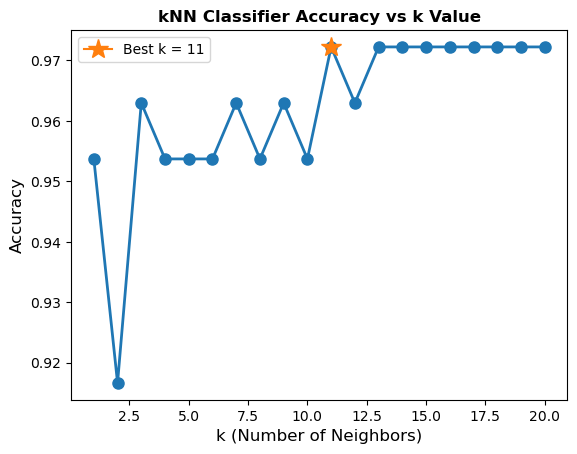

In [41]:
# Plot the results
plt.plot(k_values, accuracies, marker = 'o', linewidth = 2, markersize = 8)
plt.xlabel('k (Number of Neighbors)', fontsize = 12)
plt.ylabel('Accuracy', fontsize = 12)
plt.title('kNN Classifier Accuracy vs k Value', fontweight = 'bold')

# Mark the best k value
plt.plot(best_k, best_accuracy, marker = '*', markersize = 15, label = f'Best k = {best_k}')
plt.legend()
plt.show()

d. Finally, use two different clustering algorithms and see how well these attributes can determine the disease type (model4 and model5). 

In [12]:
# Create agglomerative metrics test, https://www.geeksforgeeks.org/machine-learning/clustering-metrics/
def agglo_test(X, y, clusters):
    # Create agglomerative model
    agg_cluster = AgglomerativeClustering(n_clusters = clusters)
    agg_cluster.fit(X)

    # Evaluate cluster
    ari = adjusted_rand_score(y, agg_cluster.labels_)
    nmi = normalized_mutual_info_score(y, agg_cluster.labels_)
    
    print("\nAgglomerative Test Summary Scores")
    print(f"Adjusted Rand Score: {str(ari)}")
    print(f"Normalized Mutual Info Score: {str(nmi)}")
    return ari, nmi, agg_cluster

In [13]:
# Create KMeans metrics test, https://www.geeksforgeeks.org/machine-learning/clustering-metrics/
def kmeans_test(X, y, clusters):
    # Create kmeans model
    kmeans_cluster = KMeans(n_clusters = clusters)
    kmeans_cluster.fit(X)

    # Evaluate cluster
    ari = adjusted_rand_score(y, kmeans_cluster.labels_)
    nmi = normalized_mutual_info_score(y, kmeans_cluster.labels_)
    
    print("\nKmeans Test Summary Scores")
    print(f"Adjusted Rand Score: {str(ari)}")
    print(f"Normalized Mutual Info Score: {str(nmi)}")
    return ari, nmi, kmeans_cluster


Agglomerative Test Summary Scores
Adjusted Rand Score: 0.7109446317046199
Normalized Mutual Info Score: 0.8685387584696121

Kmeans Test Summary Scores
Adjusted Rand Score: 0.6852220453504805
Normalized Mutual Info Score: 0.8504529652607196


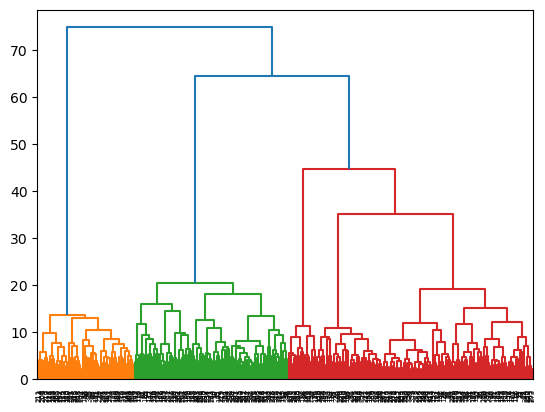

In [14]:
# Run agglomerative test with 6 clusters for disease
agg_ari, agg_nmi, agg_cluster = agglo_test(X_norm, y, 6)

# Run kmeans test with 6 clusters for diseases
kmeans_ari, kmeans_nmi, kmeans_cluster = kmeans_test(X_norm, y, 6)

# Plot a dendrogram
linked = linkage(X_norm, "ward") 
dn = dendrogram(linked)

e. Now, compare and contrast the five models you built. Having done both classification and clustering on the same dataset, what can you say about this data and/or the techniques you used? Write your thoughts in 2-3 paragraphs. 

With the first model, using gradient descent assumes that the truth label (disease) is known and allows us to converge onto a line of best fit, using the age of the patients as the X parameter. After implementing gradient descent for a multiclass logistic regression problem, we can see that the overall accuracy of the model is about 30% when only using age to predict diseases. With only age, we can see that it's not a good model and that we should include more variables for the X parameter.

With the random forest model, we see that with clinical and histopathological parameters over 100 iterations, we get an average accuracy of 97.40%, which is very high. Knowing that we have used random forest, we can mostly discount the idea of the data overfitting to cause such a high number. This most likely shows that to predict a classification for disease, the X attributes play an important role. However, as with random forest and other tree algorithms, adding additional data points could deteriorate performance.

Next, with the kNN algorithm on a 70/30 train test split, we can see that using fewer K-neighbors allows for higher accuracy. The range for highest k value tends to vary around 1 to 10, with many values containing similarly high accuracy rates. However, we can't extrapolate this to new data if it is outside our trained range; we can only use these values to evaluate our current data set range, which has a highly connected relationship.

Finally, with the clustering algorithm we see that through the performance measuring metrics of adjusted rand score index and normalized mutual info score, there is a substantial amount of agreement between the predicted and genuine class labels. With the adjusted rand index, it compares the resemblance of true class with predicted cluster labels. With the mutual information score, it measures the agreement between the true class and predicted cluster labels. Both scores in this case (>0.7, >0.85) show a high mutual agreement between the real values and predicted, which points to a high accuracy when using all X parameters to predict disease type.

With all 4 models completed, we can see that multiclass logistic regression (gradient descent) is the most unfit. However, with random forest, kNN and clustering, these algorithms are highly accurate in predicting the disease type based off the X parameters. This signals that these 3 classification models work well and that the dataset has a clear relationship involved.

### PROBLEM 2 [25 points]

Attached is a dataset

Download dataset containing statistics of hate crimes that happened within 10 days of 2016 US elections. In that period, nearly 900 hate incidents were reported to the Southern Poverty Law Center, averaging out to 90 per day. By comparison, about 36,000 hate crimes were reported to the FBI from 2010 through 2015 — an average of 16 per day.

The numbers we have here are tricky; the data is limited by how it’s collected and can’t definitively tell us whether there were more hate incidents in the days after the election than is typical. What we can do, however, is to look for trends within the numbers, such as how hate crimes vary by state, as well as what factors within those states might be tied to hate crime rates.

Use this data to answer the following questions. Use appropriate machine learning techniques/algorithms.

a. How does income inequality relate to the number of hate crimes and hate incidents? 

b. How can we predict the number of hate crimes and hate incidents from race/nature of the population? 

c. How does the number of hate crimes vary across states? Is there any similarity in number of hate incidents (per 100,000 people) between some states than in others — both according to the SPLC after the election and the FBI before it? 

Note: For the first two questions:

    Choose the variables which you think are related to the predictors (income inequality, race and nature of the population) to build your model. Justify your selection.
    Refine your model iteratively.

[Hint: You can use gradient descent, or/and add/remove variables in an incremental fashion].

d. For each of the decisions made about what techniques/algorithms to use, make sure to provide your justification or thoughts.

In [15]:
# Read in crimes dataframe
crimes_df = pd.read_csv('hatecrime.csv')
print(crimes_df.shape)

# Drop na values
crimes_df = crimes_df.dropna()
print(crimes_df.shape)

(51, 12)
(45, 12)


In [16]:
# a. How does income inequality relate to the number of hate crimes and hate incidents? 
crimes_df_const = sm.add_constant(crimes_df)

# Income inequaility X parameter (median household income)
inequality = crimes_df_const[['gini_index', 'const']].copy()

# Income parameter (median household income)
income = crimes_df_const[['median_household_income', 'const']].copy()

# Or we can use poverty 
poverty = crimes_df_const[['share_white_poverty', 'const']].copy()

# Inequality with Poverty
gini_poverty = crimes_df_const[['gini_index', 'share_white_poverty', 'const']].copy()

# Unemployment indicates a harsh economy with not many jobs
unemployment = crimes_df_const[['share_unemployed_seasonal', 'const']].copy()

# Income inequality, household income, and poverty
gini_income_poverty = crimes_df_const[['gini_index', 'share_white_poverty', 'median_household_income', 'const']].copy()

# Hate crime and hate incidents parameter (hate crime per 100,000 people)
hate_crime = crimes_df_const[['hate_crimes_per_100k_splc']].copy()

# Two continuous variables -- linear regression
print(sm.OLS(hate_crime, inequality).fit().summary())

print(sm.OLS(hate_crime, income).fit().summary())

print(sm.OLS(hate_crime, poverty).fit().summary())

print(sm.OLS(hate_crime, unemployment).fit().summary())

print(sm.OLS(hate_crime, gini_poverty).fit().summary())

print(sm.OLS(hate_crime, gini_income_poverty).fit().summary())

                                OLS Regression Results                               
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.145
Model:                                   OLS   Adj. R-squared:                  0.125
Method:                        Least Squares   F-statistic:                     7.280
Date:                       Sat, 25 Oct 2025   Prob (F-statistic):            0.00992
Time:                               09:38:25   Log-Likelihood:                 2.2752
No. Observations:                         45   AIC:                           -0.5504
Df Residuals:                             43   BIC:                             3.063
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

#### Part A Analysis (Part D)
Due to the continuous nature of the parameters, I have decided to use a linear regression model. Given the linear regression model, we can see that with a relatively low R^2 value and a small coefficient for income, there is not a high relationship between income inequality and hate crime incidents. However, using the Gini index (income inequality) we can see the R^2 value slowly rise, along with low P values (<0.05) which shows that the Gini index is statistically significant when trying to predict hate crimes per 100k of the population. By introducing another variable (share_white_poverty) to the mix, we see the R^2 value increase even more while the independent variables' P-values stay within the 0.05 threshold.

##### Reasoning For Each Iteration of Parameter Selection
1. I use the Gini index as it directly measures income inequality and can help see how that impacts number of hate crimes per 100,000 population. We see that with low P values, we can conclude that the Gini index is statistically significant; however, with a low R^2 (0.145) value signals that there are additional factors at play that can also contribute to the number of hate crimes.
2. I then try to only refer to household median income. This is to see if there is a relationship with hate crimes, perhaps as income levels continue to drop. This parameter can provide an overview of how economic conditions impact hate crimes, which could indicate that financials play a role in the relationship with hate crimes. As we can see from the model, with the P-value below 0.05, we can conclude that it is indeed significant. However, with a relatively low R^2 (0.118) value and a low coefficient (9.631e-06, slope), it does not factor in as heavily as I expected.
3. I try to use only the share of white poverty to see the singular relationship with hate crimes and the white poverty rates. This is to isolate one factor of not only race but also financial poverty levels to see if this will make a difference.  With it we see yet again another low P-value, indicating statistical significance. However, an incredibly low R^2 (0.091) value, indicating a weak relationship between the two (share of white population that's in poverty and hate crimes per 100,000 population).
4. I try to test out the unemployment rates to see if it impacts hate crimes. With higher unemployment rates, I assume that through the harsher economic struggles signaled by many people struggling to get jobs, it could lead to desperation and more hate crimes. However, we see that with a high P-value, no statistical significance, and a low R^2 value (0.016), this would not be a good parameter to include when looking for a relationship.
5. I next combine both the Gini index and share of white poverty, as previously they both showed statistical significance but had lacking R^2 values. Here we see that they continue to hold statistical significance with an increase in R^2 (0.236), a step in the right direction.
6. Finally, I combine all three of the previous factors - income inequality, median household income, and poverty - to see how it affects rates of hate crimes. Interestingly, we see the R^2 value (0.304) increases while income inequality and median household income stay strong with low P-values. However, the white poverty population parameters lose statistical significance, with a P-value above 0.05.

In [17]:
# b. How can we predict the number of hate crimes and hate incidents from race/nature of the population? 
# Population parameters include: share_unemployed_seasonal, share_population_in_metro_areas, share_population_with_high_school_degree, share_non_citizen, share_white_poverty

# Race: share_white_poverty, share_non_citizen, share_non_white
race = crimes_df_const[['share_white_poverty', 'share_non_citizen', 'share_non_white', 'const']].copy()

# Nature: share_unemployed_seasonal, share_population_in_metro_areas, share_population_with_high_school_degree, share_voters_voted_trump
nature = crimes_df_const[['share_unemployed_seasonal', 'share_population_in_metro_areas', 'share_population_with_high_school_degree', 
                          'share_voters_voted_trump', 'const']].copy()

# Combine both
race_nature = crimes_df_const.drop(['state', 'median_household_income', 'gini_index', 
                                    'hate_crimes_per_100k_splc', 'avg_hatecrimes_per_100k_fbi'], axis = 1)

print(sm.OLS(hate_crime, race).fit().summary())
print(sm.OLS(hate_crime, nature).fit().summary())
print(sm.OLS(hate_crime, race_nature).fit().summary())

                                OLS Regression Results                               
Dep. Variable:     hate_crimes_per_100k_splc   R-squared:                       0.121
Model:                                   OLS   Adj. R-squared:                  0.057
Method:                        Least Squares   F-statistic:                     1.878
Date:                       Sat, 25 Oct 2025   Prob (F-statistic):              0.148
Time:                               09:38:25   Log-Likelihood:                 1.6539
No. Observations:                         45   AIC:                             4.692
Df Residuals:                             41   BIC:                             11.92
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

 #### Part B Analysis (Part D)
Due to once again the dependent variable being continuous, I decided to use linear regression to find a relationship between the parameters.

We can see that even with race and nature both containing higher R^2 values and subsequently higher when combined, most of the parameters didn't get a P-value below 0.05, other than the share of voters that voted trump. This signals that most values could be overfitting due to too many parameters being added in. Another issue could be multicollinearity - when the parameters might be highly correlated to one another which allows the R^2 and F-test to show that the overall model is significant. However, this in turn makes the individual parameters insignificant and you can't tell which one really matters, apart from one variable. Due to this, it is safe to assume that with race/nature of the population, it is very difficult and probably not a good idea to infer from the relationship shown with hate crimes.

In [48]:
# c. How does the number of hate crimes vary across states? Is there any similarity in number of hate incidents (per 100,000 people) between some states than in others — both according to the SPLC after the election and the FBI before it? 

# Prepare data
state_crimes = crimes_df[['state', 'hate_crimes_per_100k_splc', 'avg_hatecrimes_per_100k_fbi']]
splc_crimes = crimes_df['hate_crimes_per_100k_splc'].values
splc_crimes_df = crimes_df[['hate_crimes_per_100k_splc']]
fbi_crimes = crimes_df['avg_hatecrimes_per_100k_fbi'].values
fbi_crimes_df = crimes_df[['avg_hatecrimes_per_100k_fbi']]
states = crimes_df['state'].values
crimes_cluster = crimes_df[['avg_hatecrimes_per_100k_fbi', 'hate_crimes_per_100k_splc']]

print(f"\nStates available for clustering after dropping NA values: {len(states)}")


States available for clustering after dropping NA values: 45


In [19]:
# Number of hate crimes across states
print(f"\nSPLC Hate Crimes (After Election):")
print(f"Mean: {np.mean(splc_crimes):.4f} hate crimes per 100,000 population")
print(f"Standard Deviation: {np.std(splc_crimes):.4f}")
print(f"Min: {np.min(splc_crimes):.4f} - {states[np.argmin(splc_crimes)]}")
print(f"Max: {np.max(splc_crimes):.4f} - {states[np.argmax(splc_crimes)]}")

print(f"\nFBI Hate Crimes (Before Election):")
print(f"Mean: {np.mean(fbi_crimes):.4f} hate crimes per 100,000 population")
print(f"Standard Deviation: {np.std(fbi_crimes):.4f}")
print(f"Min: {np.min(fbi_crimes):.4f} - {states[np.argmin(fbi_crimes)]}")
print(f"Max: {np.max(fbi_crimes):.4f} - {states[np.argmax(fbi_crimes)]}")


SPLC Hate Crimes (After Election):
Mean: 0.3024 hate crimes per 100,000 population
Standard Deviation: 0.2488
Min: 0.0691 - Arkansas
Max: 1.5223 - District of Columbia

FBI Hate Crimes (Before Election):
Mean: 2.3738 hate crimes per 100,000 population
Standard Deviation: 1.6994
Min: 0.4120 - Georgia
Max: 10.9535 - District of Columbia


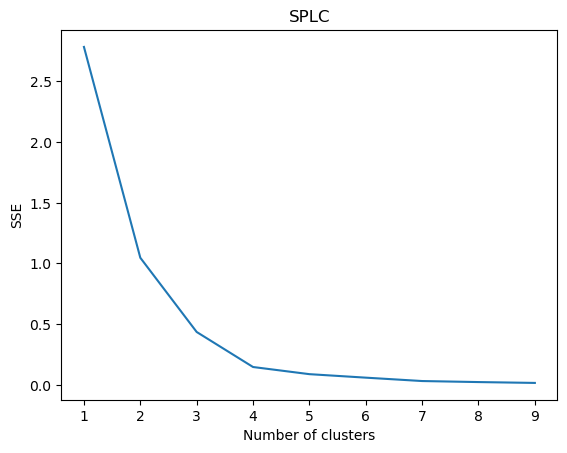

In [20]:
# Use elbow method to find optimal number of clusters for Kmean https://stackoverflow.com/questions/19197715/scikit-learn-k-means-elbow-criterion
sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters = k, max_iter = 1000, n_init = 10).fit(splc_crimes_df)
    sse[k] = kmeans.inertia_ 
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.title("SPLC")
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

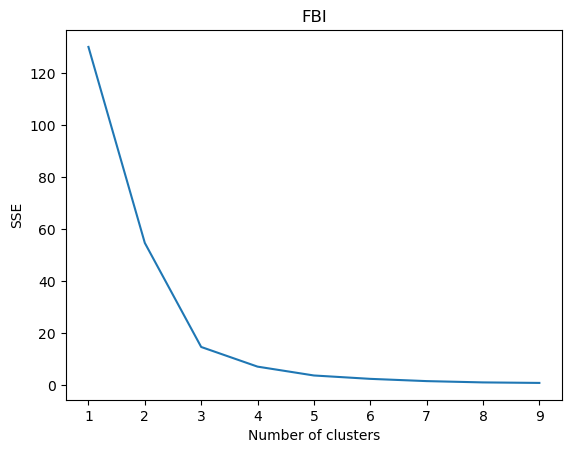

In [21]:
sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters = k, max_iter = 1000, n_init = 10).fit(fbi_crimes_df)
    sse[k] = kmeans.inertia_ 
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.title("FBI")
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

We can see that through the elbow method, we find the optimal value for k is 4 when going through SPLC data and k is 3 when going through FBI data.

In [22]:
# Run kmeans clustering with k = 3 to find clustering of states with hate crimes through FBI
fbi_kmeans = KMeans(n_clusters = 3, n_init = "auto")
fbi_labels = fbi_kmeans.fit(fbi_crimes_df).labels_
state_crimes['FBI'] = fbi_labels

# Run kmeans clustering with k = 4 to find clustering of states with hate crimes through SPLC
splc_kmeans = KMeans(n_clusters = 4, n_init = "auto")
splc_kmeans_labels = splc_kmeans.fit(splc_crimes_df).labels_
state_crimes['SPLC'] = splc_kmeans_labels

# Print out group clusters
pp.pprint(state_crimes.groupby('FBI')['state'].apply(list).to_dict()) # https://stackoverflow.com/questions/42476301/python-pretty-print-in-jupyter-notebook
pp.pprint(state_crimes.groupby('SPLC')['state'].apply(list).to_dict())

{   0: [   'Arizona',
           'Colorado',
           'Connecticut',
           'Kentucky',
           'Massachusetts',
           'Michigan',
           'Minnesota',
           'Montana',
           'Nebraska',
           'New Jersey',
           'New York',
           'Ohio',
           'Oregon',
           'Tennessee',
           'Washington'],
    1: [   'Alabama',
           'Alaska',
           'Arkansas',
           'California',
           'Delaware',
           'Florida',
           'Georgia',
           'Idaho',
           'Illinois',
           'Indiana',
           'Iowa',
           'Kansas',
           'Louisiana',
           'Maryland',
           'Missouri',
           'Nevada',
           'New Hampshire',
           'New Mexico',
           'North Carolina',
           'Oklahoma',
           'Pennsylvania',
           'Rhode Island',
           'South Carolina',
           'Texas',
           'Utah',
           'Vermont',
           'Virginia',
           'West Virgi

#### Part C Analysis (Part D)
I decided to use clustering to gain insight into the groupings of the states with their hate crime variations between SPLC and FBI data. This is due to not having a truth label; therefore, I opted to go for an unsupervised learning algorithm to gain insights on the groupings on SPLC/FBI hate crime data with their respective states.

We can see that through the groupings of the states with either SPLC or FBI data of hate crimes, there are many similarities. Through both differing cluster sizes (k = 3 or 4), we can see that District of Columbia is regularly clustered with itself, marking a huge outlier in hate crimes. The other groupings are much less jarring, with a few states grouped together in the SPLC data mingling its way into cluster 0 within FBI data. However, for the most part, clustering was very helpful in identifying what certain key groups were, with heavy emphasis on the outliers being correctly clustered farther away, maximizing dissimilarity and minimizing local variance.